# Análise exploratória de dados

### Importando os dados e pacotes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats #utilizado apenas no final por pura curiosidade

df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')
df_trips = pd.read_csv('/datasets/project_sql_result_07.csv')

### Visualizando os dados importados


#### Empresas

In [2]:
print("\n=== EMPRESAS ===")
df_companies.info()
print(df_companies.head())


=== EMPRESAS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299


#### Bairros

In [3]:
print("\n=== BAIRROS ===")
df_neighborhoods.info()
print(df_neighborhoods.head())


=== BAIRROS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


#### Corridas

In [4]:
print("\n=== CORRIDAS ===")
df_trips.info()
print(df_trips.head())


=== CORRIDAS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0


In [5]:
# Garantindo tipos corretos

df_companies['trips_amount'] = pd.to_numeric(df_companies['trips_amount'], errors='coerce')
df_neighborhoods['average_trips'] = pd.to_numeric(df_neighborhoods['average_trips'], errors='coerce')
df_trips['duration_seconds'] = pd.to_numeric(df_trips['duration_seconds'], errors='coerce')

#### Visão Geral dos dados
##### Foram analisados dois conjuntos de dados: um contendo o número de corridas por empresa de táxi e outro com o número médio de corridas por bairro de destino.

Após a inspeção inicial (info() e head()), verificou-se que os tipos de dados estão adequados para análise. As colunas numéricas (trips_amount e average_trips) estão corretamente formatadas e não apresentam inconsistências relevantes.

#### Identificação dos 10 principais bairros em termos de destinos

In [6]:
# 5. TOP 10 BAIRROS
# -----------------------------
top10_neighborhoods = df_neighborhoods.sort_values(
    by='average_trips', ascending=False
).head(10)

print("\n=== TOP 10 BAIRROS ===")
print(top10_neighborhoods)


=== TOP 10 BAIRROS ===
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


<Figure size 640x480 with 0 Axes>

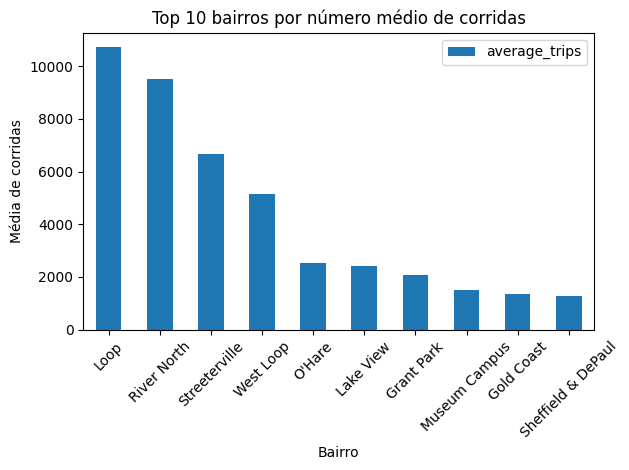

In [7]:
plt.figure()
top10_neighborhoods.plot(
    x='dropoff_location_name',
    y='average_trips',
    kind='bar'
)
plt.title('Top 10 bairros por número médio de corridas')
plt.xlabel('Bairro')
plt.ylabel('Média de corridas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Foram identificados os 10 bairros com maior número médio de corridas como destino. Os 4 bairros mais movimentados estão acima da média de 4000 corridas.
 Os bairros mais movimentados concentram uma parcela significativa das corridas, indicando regiões de alta demanda. Esses locais podem representar centros comerciais, áreas turísticas ou regiões com maior densidade populacional.

<Figure size 640x480 with 0 Axes>

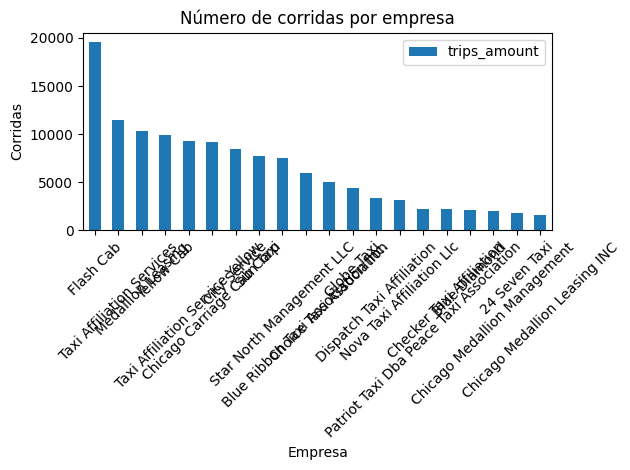

In [8]:
df_companies_sorted = df_companies.sort_values(by='trips_amount', ascending=False).head(20)

plt.figure()
df_companies_sorted.plot(
    x='company_name',
    y='trips_amount',
    kind='bar'
)
plt.title('Número de corridas por empresa')
plt.xlabel('Empresa')
plt.ylabel('Corridas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Observa-se que uma empresa concentra a maior parte das corridas, indicando um mercado dominado por uma empresa específica.

#### A análise exploratória revelou padrões importantes tanto na distribuição de corridas entre empresas quanto na concentração geográfica da demanda. Temos tanto bairros que se destacam dos demais quanto uma empresa que aparenta com clareza ser a maior do segmento.

#### Esses insights podem ser utilizados em futuras análises para:

- otimização de alocação de veículos
- estratégias competitivas
- identificação de áreas prioritárias de operação

# Testando hipóteses

### Hipótese: A duração média muda em sábados chuvosos

### Variável:
  - dependente → duration_seconds
  - categórica → weather_conditions

#### H0 (nula):
  -> A média das durações é igual

#### Formulação H0:
##### μ_rain = μ_no_rain


#### H1 (alternativa):

 -> As médias são diferentes

#### Formulação H1:
##### μ_rain ≠ μ_no_rain


 Existem 2 tipos de teste cabíveis para avaliar a diferença da média de duas amostras independentes: teste T(student e weltch) e teste Z
- teste T: não se conhece a variância e amostra pequena.
- teste Z: se conhece a variãncia ou amostra grande.


#### Pressupostos
- Independência das amostras
- Aproximação da normalidade da média (via Teorema Central do Limite, para amostras grandes)
- Igualdade de variâncias apenas no teste t de Student

-> O teste t de Welch não assume igualdade de variâncias entre os grupos. 

#### Nível de significância

Adota-se alfa = 0.05, conforme prática comum na literatura estatística.

#### Como funciona a realização do Teste:

##### Estatística do teste

A estatística t é calculada como:

- diferença entre as médias ÷ erro padrão combinado das amostras

Ou seja, mede quão distante as médias estão em relação à variabilidade dos dados.

##### p-valor e decisão

Após calcular a estatística t, obtém-se o p-valor.

- Se p-valor < α → rejeita-se H0
- Se p-valor ≥ α → não se rejeita H0
##### Interpretação

O p-valor indica a probabilidade de erro observar uma diferença entre as médias que seja extrema o suficiente em relação a alfa (onde se constroi a região crítica - R.C.), implicando na aceitação ou não da hipótese nula.

### Observação:
##### Todo o código gerado abaixo foi por pura e espontânea vontade estatística de avaliar essa situação (pois sou estatístico) e entendo que nada disso foi solicitado na solução do projeto (e sou curioso).

In [14]:
# -----------------------------
# TESTE DE HIPÓTESE (T-TEST)
# -----------------------------
from scipy import stats as st
print("Hipótese Nula - H0) As médias entre os tempos das corridas em diferentes condições é a mesma.")
print("Hipótese Alternativa - H1) As médias entre os tempos das corridas em diferentes condições são diferentes entre si.")


rain = df_trips[df_trips['weather_conditions'] == 'Bad']['duration_seconds']
no_rain = df_trips[df_trips['weather_conditions'] == 'Good']['duration_seconds']

print("\nTamanho amostra chuva:", len(rain))
print("Tamanho amostra sem chuva:", len(no_rain))


alpha = 0.05 #(5% da literatura estatística)
# curiosidade: não existe nada sobre o porquê utilizar os 5% com fundamentos exatos
# basicamente um dia uma pessoa utilizou e as outras copiaram... hahahaha


# descobrir se as variâncias são diferentes
var_bad = rain.var()
var_good = no_rain.var()

levene_stat, levene_pvalue = st.levene(rain, no_rain, center='median')

print("Variância dias chuvosos:", var_bad)
print("Variância dias bons:", var_good)
print("Estatística de Levene:", levene_stat)
print("p-value de Levene:", levene_pvalue)
if levene_pvalue < alpha: 
    print("Variâncias suficientemente diferentes.") 
else: 
        print("Variâncias são iguais ou suficientemente parecidas.")


# Welch's t-test
stat, p_value = stats.ttest_ind(rain, no_rain, equal_var=False)

print("\nEstatística do Teste-t de Welch:", stat)
print("p-valor:", p_value)

SyntaxError: invalid syntax (1610914467.py, line 33)

In [ ]:
# -----------------------------
# 10. DECISÃO
# -----------------------------

if p_value < alpha:
    print("Rejeitamos H0: há diferença significativa nas durações. (p-valor < alpha = Dentro da Zona crítica)")
else:
    print("Não rejeitamos H0: não há evidência de diferença.(p-valor > alpha = Fora da Zona Crítica)")

##### Há evidências estatísticas de que as condições climáticas impactam a duração das corridas. Em dias chuvosos, a duração média das viagens difere significativamente em relação aos dias sem chuva.

-> Fica como recomendação futura a criação de outros gráficos para entender melhor o quanto difere e se isso possui relação com bairros etc...